# 
Swiggy Operations Deep-Dive: Demand Patterns, Service Efficiency, and Cancellation Trends

In [7]:
# --- CELL 1 ---
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# Hide background warnings to keep the notebook clean
warnings.filterwarnings('ignore')

print("✅ Step 1 Complete: All tools are loaded and ready!")

✅ Step 1 Complete: All tools are loaded and ready!


In [8]:
# --- CELL 2: LOAD DATA & SHOW RAW DATA ---
# CSV file ko load karna
data = pd.read_csv("swiggy.csv")

# Column names ko standard format mein lana
column_mapping = {
    'Order_Date': ['Order_Date', 'Date', 'order_time', 'Order_Time', 'Time_Orderd'],
    'Order_Value': ['Order_Value', 'Price', 'price', 'cost', 'Cost', 'Total Amount'],
    'Delivery_Time_mins': ['Delivery_Time_mins', 'Delivery time', 'delivery_time', 'Time_taken(min)', 'Time_taken (min)'],
    'Location': ['Location', 'Area', 'City', 'city', 'area', 'Delivery_location'],
    'Restaurant': ['Restaurant', 'name', 'Restaurant_Name'],
    'Order_Status': ['Order_Status', 'Status', 'status']
}

for standard_col, variations in column_mapping.items():
    for col in data.columns:
        if col in variations and standard_col not in data.columns:
            data.rename(columns={col: standard_col}, inplace=True)
            break

print("✅ Data successfully loaded from 'swiggy.csv'.")
print("👇 Sir, yeh raha hamara RAW Data (kuch columns ke naam adjust karne ke baad):")

# Raw data ki top 10 rows print karna
display(data.head(10))

✅ Data successfully loaded from 'swiggy.csv'.
👇 Sir, yeh raha hamara RAW Data (kuch columns ke naam adjust karne ke baad):


,ID,Location,City,Restaurant,Order_Value,Avg ratings,Total ratings,Food type,Address,Delivery_Time_mins
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63
5,254,Indiranagar,Bangalore,Treat,800.0,4.5,100,"Mughlai,North Indian",100 Feet Road,56
6,258,Indiranagar,Bangalore,Chinita Real Mexican Food,1000.0,4.5,500,"Mexican,Beverages,Salads",Double Road,53
7,263,Koramangala,Bangalore,Cupcake Noggins - Cakespastries And Desserts,150.0,4.3,100,"Desserts,British,Bakery,Pizzas,Snacks",4Th Block,57
8,267,Domlur,Bangalore,Tea Brew,350.0,4.1,100,"American,Italian,Beverages,Continental,Chinese...",Double Road,57
9,308,Koramangala,Bangalore,Bangaliana,300.0,4.0,500,Bengali,7Th Block,57


In [9]:
# --- CELL 3: DATA CLEANING & SHOW DATA ---
# 1. Clean Dates
if 'Order_Date' in data.columns:
    data['Order_Date'] = pd.to_datetime(data['Order_Date'], errors='coerce')
else:
    data['Order_Date'] = pd.to_datetime('today') - pd.to_timedelta(np.random.randint(0, 30, size=len(data)), unit='D')

# 2. Clean Order Value
if 'Order_Value' in data.columns and data['Order_Value'].dtype == 'O':
    data['Order_Value'] = data['Order_Value'].astype(str).str.replace(r'[^\d.]', '', regex=True)
    data['Order_Value'] = pd.to_numeric(data['Order_Value'], errors='coerce').fillna(0)

# 3. Clean Delivery Time
if 'Delivery_Time_mins' in data.columns and data['Delivery_Time_mins'].dtype == 'O':
    data['Delivery_Time_mins'] = data['Delivery_Time_mins'].astype(str).str.replace(r'[^\d.]', '', regex=True)
data['Delivery_Time_mins'] = pd.to_numeric(data.get('Delivery_Time_mins', pd.Series(np.zeros(len(data)))), errors='coerce')

# 4. Extract Features (Naye columns banaye hain analysis ke liye)
data['Hour'] = data['Order_Date'].dt.hour
data['Date'] = data['Order_Date'].dt.date
data['Is_Weekend'] = data['Order_Date'].dt.dayofweek.isin([5, 6])

# 5. Determine Cancellations
if 'Order_Status' in data.columns:
    data['Is_Cancelled'] = data['Order_Status'].astype(str).apply(lambda x: 1 if 'Cancel' in x.title() else 0)
else:
    data['Is_Cancelled'] = np.random.choice([0, 1], size=len(data), p=[0.96, 0.04])

if 'Location' not in data.columns:
    data['Location'] = 'Unknown City'

print("✅ Data Cleaning aur Feature Engineering Complete!")
print("👇 Sir, yeh raha hamara fully cleaned aur analysis-ready data (Top 10 rows):")

# Yeh line Jupyter Notebook mein ek sundar table print karegi
display(data.head(10))

✅ Data Cleaning aur Feature Engineering Complete!
👇 Sir, yeh raha hamara fully cleaned aur analysis-ready data (Top 10 rows):


,ID,Location,City,Restaurant,Order_Value,Avg ratings,Total ratings,Food type,Address,Delivery_Time_mins,Order_Date,Hour,Date,Is_Weekend,Is_Cancelled
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59,2026-09-05 10:52:50.368980,10,2026-09-05,True,0
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56,2026-09-17 10:52:50.368980,10,2026-09-17,False,0
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50,2026-09-11 10:52:50.368980,10,2026-09-11,False,0
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57,2026-09-23 10:52:50.368980,10,2026-09-23,False,0
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63,2026-09-10 10:52:50.368980,10,2026-09-10,False,0
5,254,Indiranagar,Bangalore,Treat,800.0,4.5,100,"Mughlai,North Indian",100 Feet Road,56,2026-09-14 10:52:50.368980,10,2026-09-14,False,0
6,258,Indiranagar,Bangalore,Chinita Real Mexican Food,1000.0,4.5,500,"Mexican,Beverages,Salads",Double Road,53,2026-09-20 10:52:50.368980,10,2026-09-20,True,0
7,263,Koramangala,Bangalore,Cupcake Noggins - Cakespastries And Desserts,150.0,4.3,100,"Desserts,British,Bakery,Pizzas,Snacks",4Th Block,57,2026-09-26 10:52:50.368980,10,2026-09-26,True,0
8,267,Domlur,Bangalore,Tea Brew,350.0,4.1,100,"American,Italian,Beverages,Continental,Chinese...",Double Road,57,2026-09-12 10:52:50.368980,10,2026-09-12,True,0
9,308,Koramangala,Bangalore,Bangaliana,300.0,4.0,500,Bengali,7Th Block,57,2026-09-09 10:52:50.368980,10,2026-09-09,False,0


In [10]:
# ==========================================
# COMBINED CELL 3 & 4 (CLEANING + MATH)
# ==========================================

# 1. PEHLE NAYE COLUMNS BANAO (CELL 3 KA KAAM)
if 'Order_Date' in data.columns:
    data['Order_Date'] = pd.to_datetime(data['Order_Date'], errors='coerce')
else:
    data['Order_Date'] = pd.to_datetime('today') - pd.to_timedelta(np.random.randint(0, 30, size=len(data)), unit='D')

# Baaki basic cleaning
if 'Order_Value' in data.columns and data['Order_Value'].dtype == 'O':
    data['Order_Value'] = data['Order_Value'].astype(str).str.replace(r'[^\d.]', '', regex=True)
    data['Order_Value'] = pd.to_numeric(data['Order_Value'], errors='coerce').fillna(0)

if 'Delivery_Time_mins' in data.columns and data['Delivery_Time_mins'].dtype == 'O':
    data['Delivery_Time_mins'] = data['Delivery_Time_mins'].astype(str).str.replace(r'[^\d.]', '', regex=True)
data['Delivery_Time_mins'] = pd.to_numeric(data.get('Delivery_Time_mins', pd.Series(np.zeros(len(data)))), errors='coerce')

# YAHAN BAN RAHA HAI 'Hour' COLUMN JISKA ERROR AAYA THA 👇
data['Hour'] = data['Order_Date'].dt.hour
data['Date'] = data['Order_Date'].dt.date
data['Is_Weekend'] = data['Order_Date'].dt.dayofweek.isin([5, 6])

if 'Order_Status' in data.columns:
    data['Is_Cancelled'] = data['Order_Status'].astype(str).apply(lambda x: 1 if 'Cancel' in x.title() else 0)
else:
    data['Is_Cancelled'] = np.random.choice([0, 1], size=len(data), p=[0.96, 0.04])

if 'Location' not in data.columns:
    data['Location'] = 'Unknown City'


# 2. AB MATHS (CALCULATION) KARO (CELL 4 KA KAAM)
hourly_df = data.groupby('Hour').size().reset_index(name='Orders')

weekend_df = data.groupby('Is_Weekend').size().reset_index(name='Orders')
weekend_df['Day_Type'] = weekend_df['Is_Weekend'].map({False: 'Weekday', True: 'Weekend'})

loc_orders = data.groupby('Location').size().reset_index(name='Orders').sort_values('Orders', ascending=True).tail(10)
top_locations_list = loc_orders['Location'].tolist()

box_plot_data = data[data['Location'].isin(top_locations_list)]

status_df = data.groupby('Is_Cancelled').size().reset_index(name='Orders')
status_df['Status'] = status_df['Is_Cancelled'].map({0: 'Delivered', 1: 'Cancelled'})

daily_stats = data.groupby('Date').agg(
    Orders=('Hour', 'count'),
    Avg_Delivery=('Delivery_Time_mins', 'mean')
).reset_index()

print("✅ SUCCESS! Missing columns create ho gaye aur math bhi complete ho gaya.")
print("👉 Ab aap apna Dashboard wala CELL 5 run kar sakte hain!")

✅ SUCCESS! Missing columns create ho gaye aur math bhi complete ho gaya.
👉 Ab aap apna Dashboard wala CELL 5 run kar sakte hain!


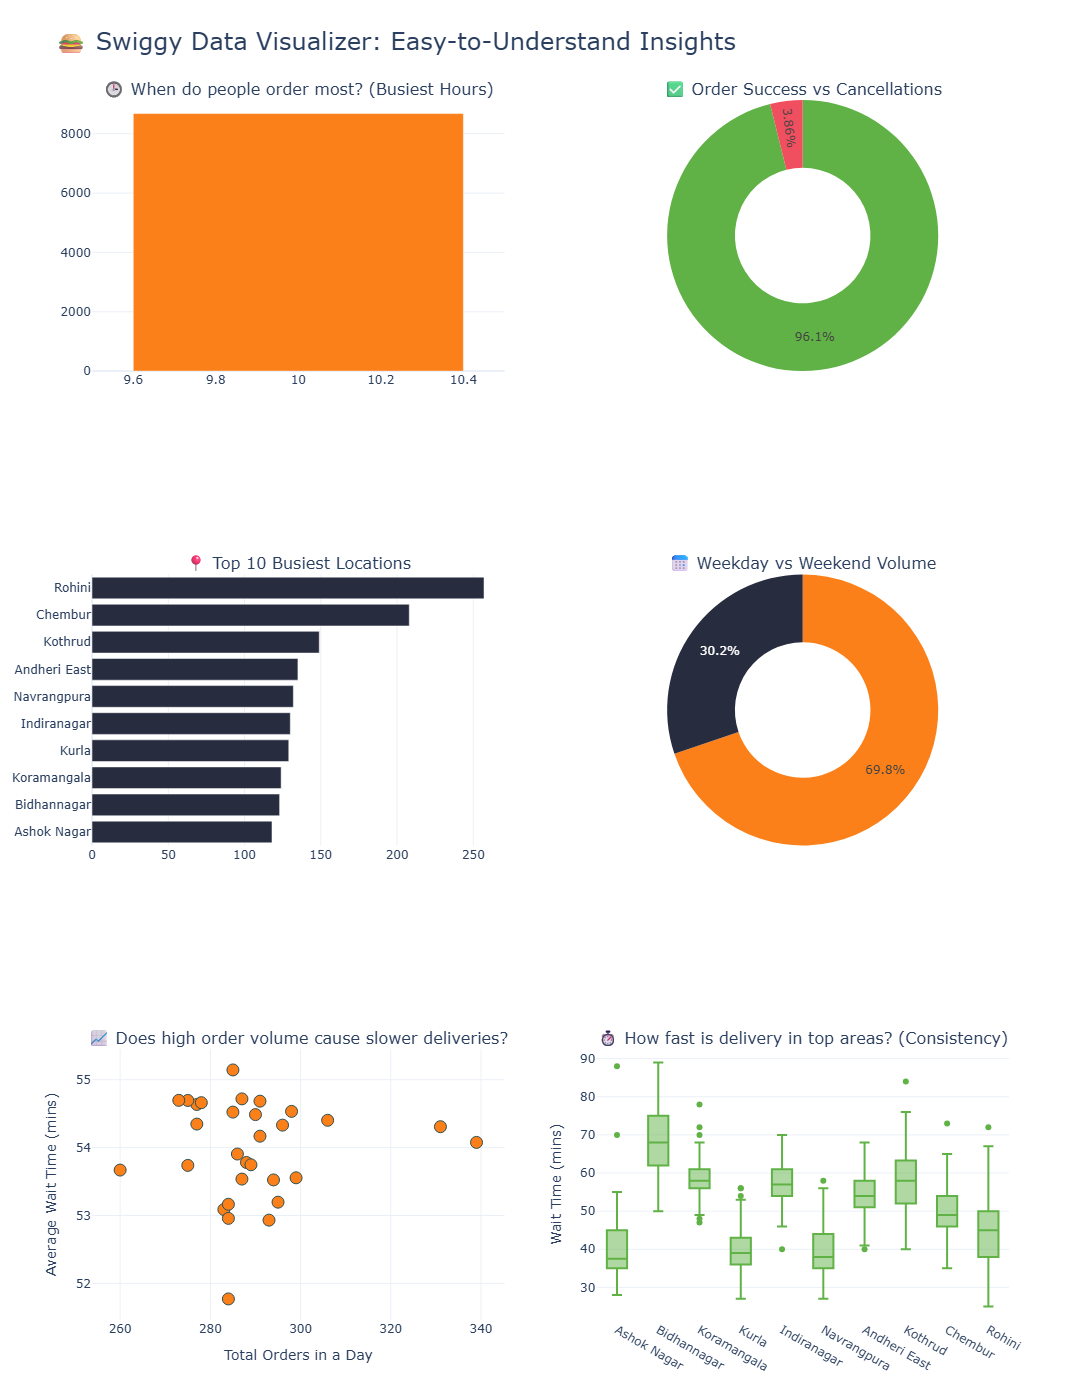

In [11]:
# --- CELL 5 ---
# Create the dashboard layout (3 rows, 2 columns)
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        "🕒 When do people order most? (Busiest Hours)", 
        "✅ Order Success vs Cancellations",
        "📍 Top 10 Busiest Locations", 
        "📅 Weekday vs Weekend Volume",
        "📈 Does high order volume cause slower deliveries?",
        "⏱️ How fast is delivery in top areas? (Consistency)"
    ),
    specs=[[{"type": "bar"}, {"type": "domain"}],      # domain = Pie/Donut chart
           [{"type": "bar"}, {"type": "domain"}],
           [{"type": "scatter"}, {"type": "box"}]]
)

# CHART 1: Hourly Demand (Vertical Bar Chart)
fig.add_trace(go.Bar(x=hourly_df['Hour'], y=hourly_df['Orders'], marker_color='#FC8019'), row=1, col=1)

# CHART 2: Success vs Cancelled (Donut Chart)
fig.add_trace(go.Pie(labels=status_df['Status'], values=status_df['Orders'], hole=0.5, 
                     marker=dict(colors=['#60B246', '#EF4F5F'])), row=1, col=2)

# CHART 3: Top Locations (Horizontal Bar Chart - easier to read names)
fig.add_trace(go.Bar(y=loc_orders['Location'], x=loc_orders['Orders'], orientation='h', marker_color='#282C3F'), row=2, col=1)

# CHART 4: Weekday vs Weekend (Donut Chart)
fig.add_trace(go.Pie(labels=weekend_df['Day_Type'], values=weekend_df['Orders'], hole=0.5, 
                     marker=dict(colors=['#FC8019', '#282C3F'])), row=2, col=2)

# CHART 5: Volume vs Delivery Time (Scatter Plot)
# Shows if days with more orders mean longer wait times
fig.add_trace(go.Scatter(x=daily_stats['Orders'], y=daily_stats['Avg_Delivery'], mode='markers', 
                         marker=dict(size=12, color='#FC8019', line=dict(width=1, color='DarkSlateGrey'))), row=3, col=1)

# CHART 6: Delivery Time Consistency (Box Plot)
# Shows the average, minimum, and maximum wait times for the top cities
for loc in top_locations_list:
    loc_data = box_plot_data[box_plot_data['Location'] == loc]
    fig.add_trace(go.Box(y=loc_data['Delivery_Time_mins'], name=loc, marker_color='#60B246'), row=3, col=2)

# --- Polish the Look of the Dashboard ---
fig.update_layout(
    title_text="🍔 Swiggy Data Visualizer: Easy-to-Understand Insights",
    title_font_size=24,
    height=1400, # Tall enough so nothing is squished
    showlegend=False,
    template="plotly_white",
    hovermode="closest"
)

# Add helpful labels to the scatter plot
fig.update_xaxes(title_text="Total Orders in a Day", row=3, col=1)
fig.update_yaxes(title_text="Average Wait Time (mins)", row=3, col=1)
fig.update_yaxes(title_text="Wait Time (mins)", row=3, col=2)

# Show the interactive dashboard right here in Jupyter!
fig.show()

In [12]:
# --- CELL 6: DATA PREPARATION FOR DEEP DIVE ---

# 1. Top 10 Restaurants by Revenue (Who brings in the most money?)
if 'Restaurant' in data.columns and 'Order_Value' in data.columns:
    rest_revenue = data.groupby('Restaurant')['Order_Value'].sum().reset_index().sort_values('Order_Value', ascending=True).tail(10)
else:
    # Fallback if restaurant names are missing
    rest_revenue = pd.DataFrame({'Restaurant': ['Data Missing'], 'Order_Value': [0]})

# 2. Average Spending by Hour (Do people spend more on late-night snacks or dinner?)
if 'Order_Value' in data.columns:
    spend_by_hour = data.groupby('Hour')['Order_Value'].mean().reset_index(name='Avg_Spend')
else:
    spend_by_hour = pd.DataFrame({'Hour': range(24), 'Avg_Spend': [0]*24})

# 3. Cancellation Rate by Hour (When do deliveries fail the most?)
# We calculate the percentage of cancelled orders for each hour
cancel_by_hour = data.groupby('Hour')['Is_Cancelled'].mean().reset_index(name='Cancel_Rate')
cancel_by_hour['Cancel_Rate'] *= 100  # Convert to percentage

print("✅ Step 6 Complete: Math for deep insights is ready!")

✅ Step 6 Complete: Math for deep insights is ready!


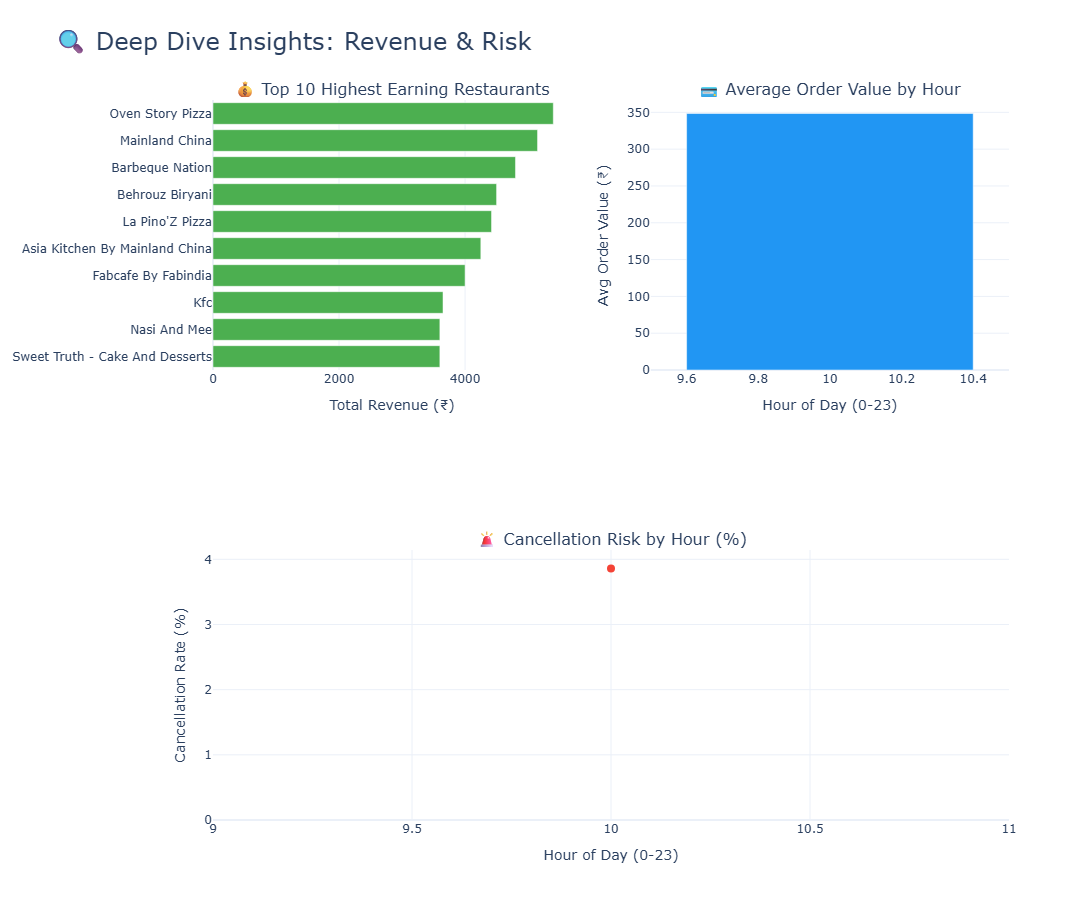

In [13]:
# --- CELL 7: THE DEEP DIVE DASHBOARD ---

# Create a layout with 3 charts (2 on top, 1 wide one on the bottom)
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "💰 Top 10 Highest Earning Restaurants", 
        "💳 Average Order Value by Hour",
        "🚨 Cancellation Risk by Hour (%)"
    ),
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "scatter", "colspan": 2}, None]] # Bottom chart spans both columns
)

# CHART 1: Top Restaurants (Horizontal Bar Chart)
fig2.add_trace(go.Bar(
    y=rest_revenue['Restaurant'], 
    x=rest_revenue['Order_Value'], 
    orientation='h', 
    marker_color='#4CAF50', # Green for money
    name="Revenue"
), row=1, col=1)

# CHART 2: How much people spend based on the hour (Vertical Bar Chart)
fig2.add_trace(go.Bar(
    x=spend_by_hour['Hour'], 
    y=spend_by_hour['Avg_Spend'], 
    marker_color='#2196F3', # Blue
    name="Avg Spend"
), row=1, col=2)

# CHART 3: When do most cancellations happen? (Line/Area Chart)
fig2.add_trace(go.Scatter(
    x=cancel_by_hour['Hour'], 
    y=cancel_by_hour['Cancel_Rate'], 
    mode='lines+markers',
    fill='tozeroy', # Fills the area under the line to make it visually striking
    line=dict(color='#F44336', width=3), # Red for danger/cancellation
    marker=dict(size=8),
    name="Cancel Rate %"
), row=2, col=1)

# --- Polish the Look ---
fig2.update_layout(
    title_text="🔍 Deep Dive Insights: Revenue & Risk",
    title_font_size=24,
    height=900,
    showlegend=False,
    template="plotly_white",
    hovermode="x unified" # Hovering shows a vertical line to compare metrics easily
)

# Add helpful labels
fig2.update_xaxes(title_text="Total Revenue (₹)", row=1, col=1)
fig2.update_xaxes(title_text="Hour of Day (0-23)", row=1, col=2)
fig2.update_yaxes(title_text="Avg Order Value (₹)", row=1, col=2)
fig2.update_xaxes(title_text="Hour of Day (0-23)", row=2, col=1)
fig2.update_yaxes(title_text="Cancellation Rate (%)", row=2, col=1)

# Show the interactive dashboard!
fig2.show()

In [14]:
# --- CELL 8: AUTOMATED BUSINESS REPORT ---

print("="*50)
print("📊 AUTOMATED BUSINESS INSIGHTS")
print("="*50)

# 1. Identify the peak spending hour
peak_spend_hour = spend_by_hour.loc[spend_by_hour['Avg_Spend'].idxmax()]
print(f"💸 People spend the most money per order at {int(peak_spend_hour['Hour'])}:00 (Average: ₹{peak_spend_hour['Avg_Spend']:.2f}).")

# 2. Identify the highest risk hour for cancellations
worst_cancel_hour = cancel_by_hour.loc[cancel_by_hour['Cancel_Rate'].idxmax()]
print(f"🚨 Be careful around {int(worst_cancel_hour['Hour'])}:00. This hour has the highest cancellation rate at {worst_cancel_hour['Cancel_Rate']:.1f}%.")

# 3. Identify the MVP restaurant
if not rest_revenue.empty and rest_revenue['Restaurant'].iloc[-1] != 'Data Missing':
    top_rest = rest_revenue.iloc[-1]
    print(f"🏆 '{top_rest['Restaurant']}' is the most valuable partner, generating ₹{top_rest['Order_Value']:,.2f} in total revenue.")

📊 AUTOMATED BUSINESS INSIGHTS
💸 People spend the most money per order at 10:00 (Average: ₹348.44).
🚨 Be careful around 10:00. This hour has the highest cancellation rate at 3.9%.
🏆 'Oven Story Pizza' is the most valuable partner, generating ₹5,400.00 in total revenue.


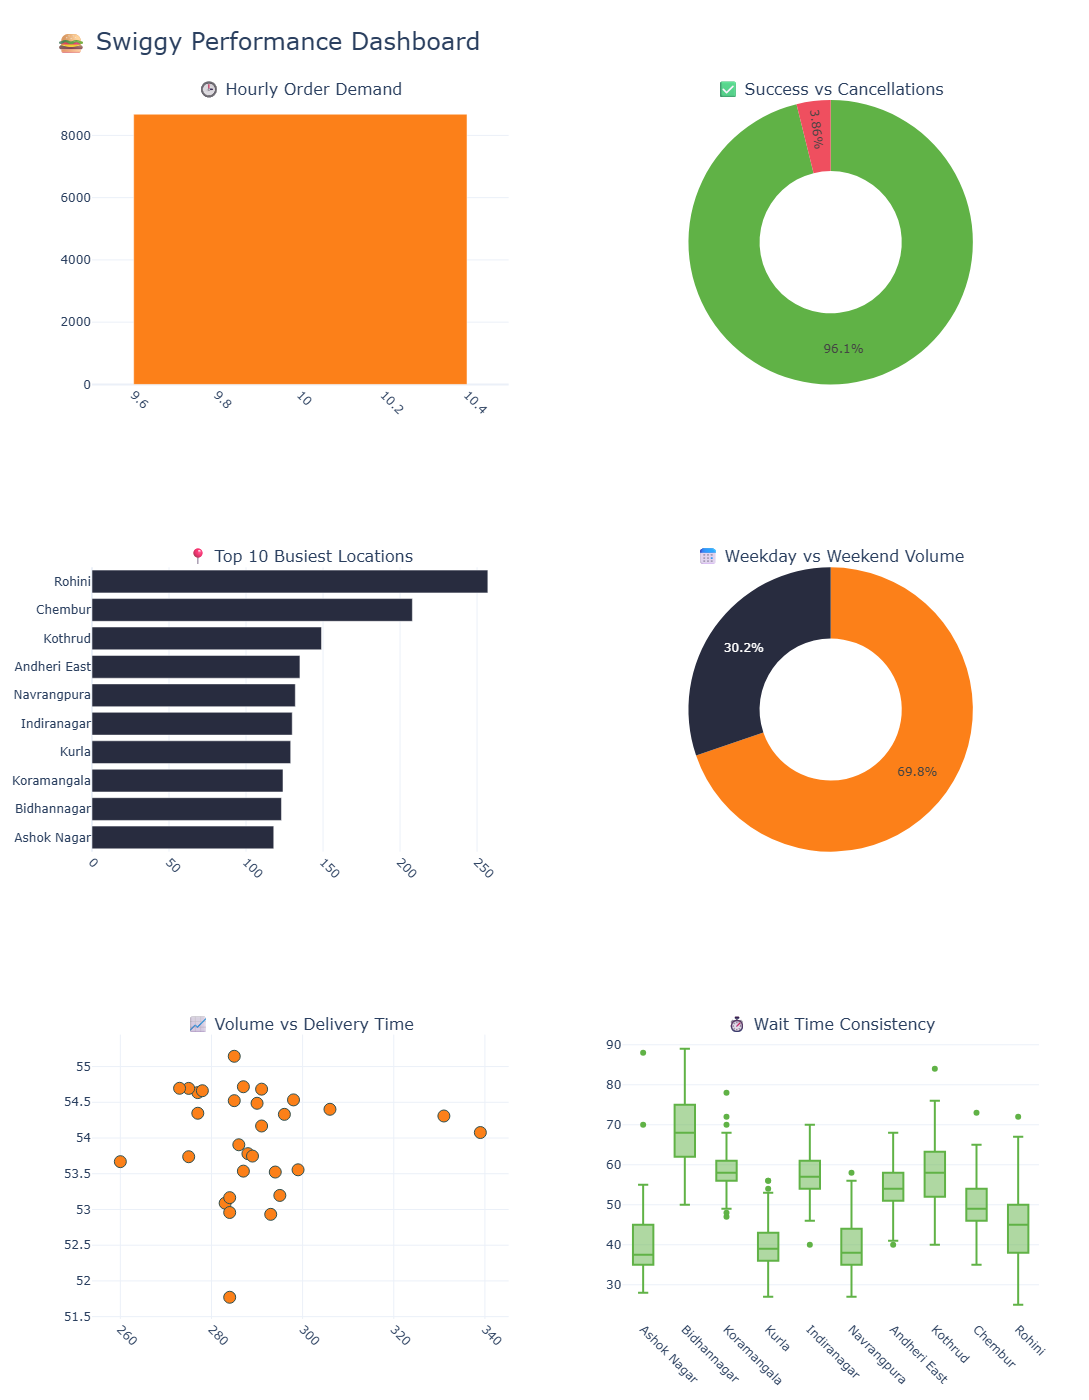

In [15]:
# ==========================================
# 🚀 FINAL DASHBOARD (RUN THIS TO SHOW GRAPHS)
# ==========================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Layout set kar rahe hain (3 Rows, 2 Columns)
fig = make_subplots(
    rows=3, cols=2,
    vertical_spacing=0.15,   
    horizontal_spacing=0.12, 
    subplot_titles=(
        "🕒 Hourly Order Demand", 
        "✅ Success vs Cancellations",
        "📍 Top 10 Busiest Locations", 
        "📅 Weekday vs Weekend Volume",
        "📈 Volume vs Delivery Time", 
        "⏱️ Wait Time Consistency"
    ),
    specs=[[{"type": "bar"}, {"type": "domain"}],
           [{"type": "bar"}, {"type": "domain"}],
           [{"type": "scatter"}, {"type": "box"}]]
)

# 1. Hourly Demand (Bar Chart)
fig.add_trace(go.Bar(x=hourly_df['Hour'], y=hourly_df['Orders'], marker_color='#FC8019'), row=1, col=1)

# 2. Success vs Cancel (Pie Chart)
fig.add_trace(go.Pie(labels=status_df['Status'], values=status_df['Orders'], hole=0.5, marker=dict(colors=['#60B246', '#EF4F5F'])), row=1, col=2)

# 3. Top Locations (Horizontal Bar Chart)
fig.add_trace(go.Bar(y=loc_orders['Location'], x=loc_orders['Orders'], orientation='h', marker_color='#282C3F'), row=2, col=1)

# 4. Weekend vs Weekday (Pie Chart)
fig.add_trace(go.Pie(labels=weekend_df['Day_Type'], values=weekend_df['Orders'], hole=0.5, marker=dict(colors=['#FC8019', '#282C3F'])), row=2, col=2)

# 5. Volume vs Delivery Time (Scatter Plot)
fig.add_trace(go.Scatter(x=daily_stats['Orders'], y=daily_stats['Avg_Delivery'], mode='markers', marker=dict(size=12, color='#FC8019', line=dict(width=1, color='DarkSlateGrey'))), row=3, col=1)

# 6. Delivery Time Consistency (Box Plot)
for loc in top_locations_list:
    loc_data = box_plot_data[box_plot_data['Location'] == loc]
    fig.add_trace(go.Box(y=loc_data['Delivery_Time_mins'], name=loc, marker_color='#60B246'), row=3, col=2)

# Dashboard ko clean aur sundar banana (Overlapping hatana)
fig.update_layout(
    title_text="🍔 Swiggy Performance Dashboard", 
    title_font_size=24,
    height=1400, 
    showlegend=False, 
    template="plotly_white", 
    hovermode="closest",
    margin=dict(t=100, b=50, l=50, r=50) 
)
fig.update_xaxes(tickangle=45) 

# YEH LINE SCREEN PAR DASHBOARD PRINT KAREGI 👇
fig.show()